In [14]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx 
import geopandas as gpd
import os

In [15]:
folder_path = r"C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara"
tala_path = os.path.join(folder_path, "TALA")

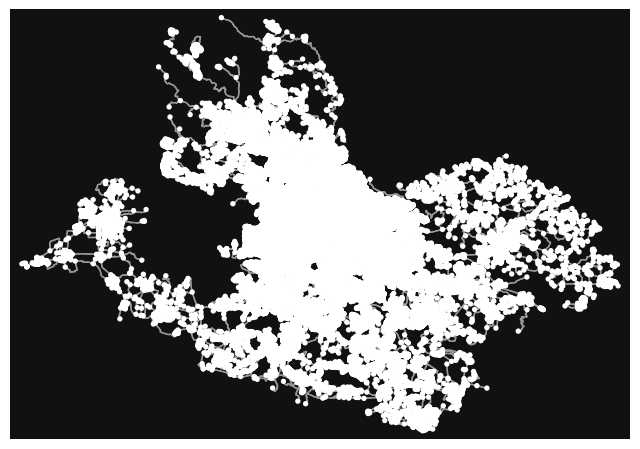

In [ ]:
AMG_Polygon = gpd.read_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Importacion TransCAD\Limites Municipales\AMG\AMG_SHAPE.shp')

tala_gdf = ox.geocode_to_gdf("Tala, Jalisco, Mexico")
AMG_Polygon = AMG_Polygon.to_crs(tala_gdf.crs)

# Unir ZMG + Tala
area_gdf = pd.concat([AMG_Polygon, tala_gdf], ignore_index=True)
area_gdf = area_gdf.to_crs(32613)
area_union = area_gdf.geometry.union_all()

# Buffer para asegurar conexión carretera
area_buffer = area_union.buffer(3000)
# Regresar a WGS84 para OSMnx
area_buffer_gdf = gpd.GeoDataFrame(geometry=[area_buffer], crs=32613).to_crs(4326)

"""G = ox.graph_from_polygon(
    area_union,
    network_type="drive",
    simplify=True
)"""
G_nuevo = ox.graph_from_polygon(
    area_buffer_gdf.geometry.iloc[0],
    network_type="drive",
    simplify=True,
    retain_all=False
)
fig, ax = ox.plot_graph(G_nuevo)

In [18]:
nx.number_weakly_connected_components(G)

1

In [20]:
nodes, edges = ox.graph_to_gdfs(G_nuevo)
nodes.to_file(os.path.join(tala_path,"tala_nodes2.shp"))
edges.to_file(os.path.join(tala_path,"tala_edges2.shp"))

C:\Users\AP03542515\AppData\Local\Temp\2\ipykernel_70140\3384587118.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file(os.path.join(tala_path,"tala_nodes2.shp"))
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(
c:\Users\AP03542515\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value '[1135990913, 1135990915, 1135990925, 1135990927, 1417643155, 1417643158, 1135990936, 1135990937, 1290072088, 1249664052, 1249664053, 1249664054, 1249664055, 1249664056, 1249664058, 1249664059, 1249664061, 1249664062, 1386358746, 1386358747, 1135990877, 1135990878, 1135990879, 1135990880, 1135990887, 1135990889, 1135990901, 1392865278]' of field osmid has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(


In [21]:
edges = edges.reset_index()
print(edges.columns)

Index(['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'name', 'oneway',
       'reversed', 'length', 'geometry', 'ref', 'bridge', 'maxspeed',
       'junction', 'tunnel', 'access', 'width'],
      dtype='object')


In [22]:
nodes

,y,x,street_count,highway,ref,junction,railway,geometry
osmid,,,,,,,,
130153606,20.669240,-103.341135,4,NaN,NaN,NaN,NaN,POINT (-103.34114 20.66924)
130154244,20.674854,-103.356867,3,NaN,NaN,NaN,NaN,POINT (-103.35687 20.67485)
267537966,20.616062,-103.246323,3,motorway_junction,NaN,NaN,NaN,POINT (-103.24632 20.61606)
267537978,20.628507,-103.291851,3,motorway_junction,NaN,NaN,NaN,POINT (-103.29185 20.62851)
267537985,20.628819,-103.296318,3,NaN,NaN,NaN,NaN,POINT (-103.29632 20.62882)
...,...,...,...,...,...,...,...,...
12834514636,20.743109,-103.638137,1,NaN,NaN,NaN,NaN,POINT (-103.63814 20.74311)
12834514637,20.743154,-103.637789,3,NaN,NaN,NaN,NaN,POINT (-103.63779 20.74315)
12834514638,20.742983,-103.638046,1,NaN,NaN,NaN,NaN,POINT (-103.63805 20.74298)
